# Variance Ratio Test

This notebook illustrates the Variance Ratio test on crypto data.

Under a random walk, the variance of a `q`-period return should be about `q` times the variance of a 1-period return. The variance ratio is therefore:

$$
VR(q) = \frac{\mathrm{Var}(r_t(q))}{q \cdot \mathrm{Var}(r_t(1))}.
$$

Interpretation:

- $VR(q) \approx 1$: consistent with a random walk
- $VR(q) < 1$: mean reversion
- $VR(q) > 1$: momentum or trending

In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import vectorbt as vbt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

/opt/conda/lib/python3.11/site-packages/apscheduler/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# Daily crypto data from Binance via CCXT
symbol = "BTC/USDT"
timeframe = "1d"
start = "2022-01-01 UTC"
end = "2024-12-31 UTC"

data = vbt.CCXTData.download(
    symbol,
    exchange="binance",
    timeframe=timeframe,
    start=start,
    end=end,
    show_progress=True,
)

close = data.get("Close").dropna()
log_price = np.log(close)
log_return = log_price.diff().dropna()

log_return.tail()

0it [00:00, ?it/s]

Open time
2024-12-26 00:00:00+00:00   -0.037275
2024-12-27 00:00:00+00:00   -0.015704
2024-12-28 00:00:00+00:00    0.010559
2024-12-29 00:00:00+00:00   -0.016524
2024-12-30 00:00:00+00:00   -0.010145
Freq: D, Name: Close, dtype: float64

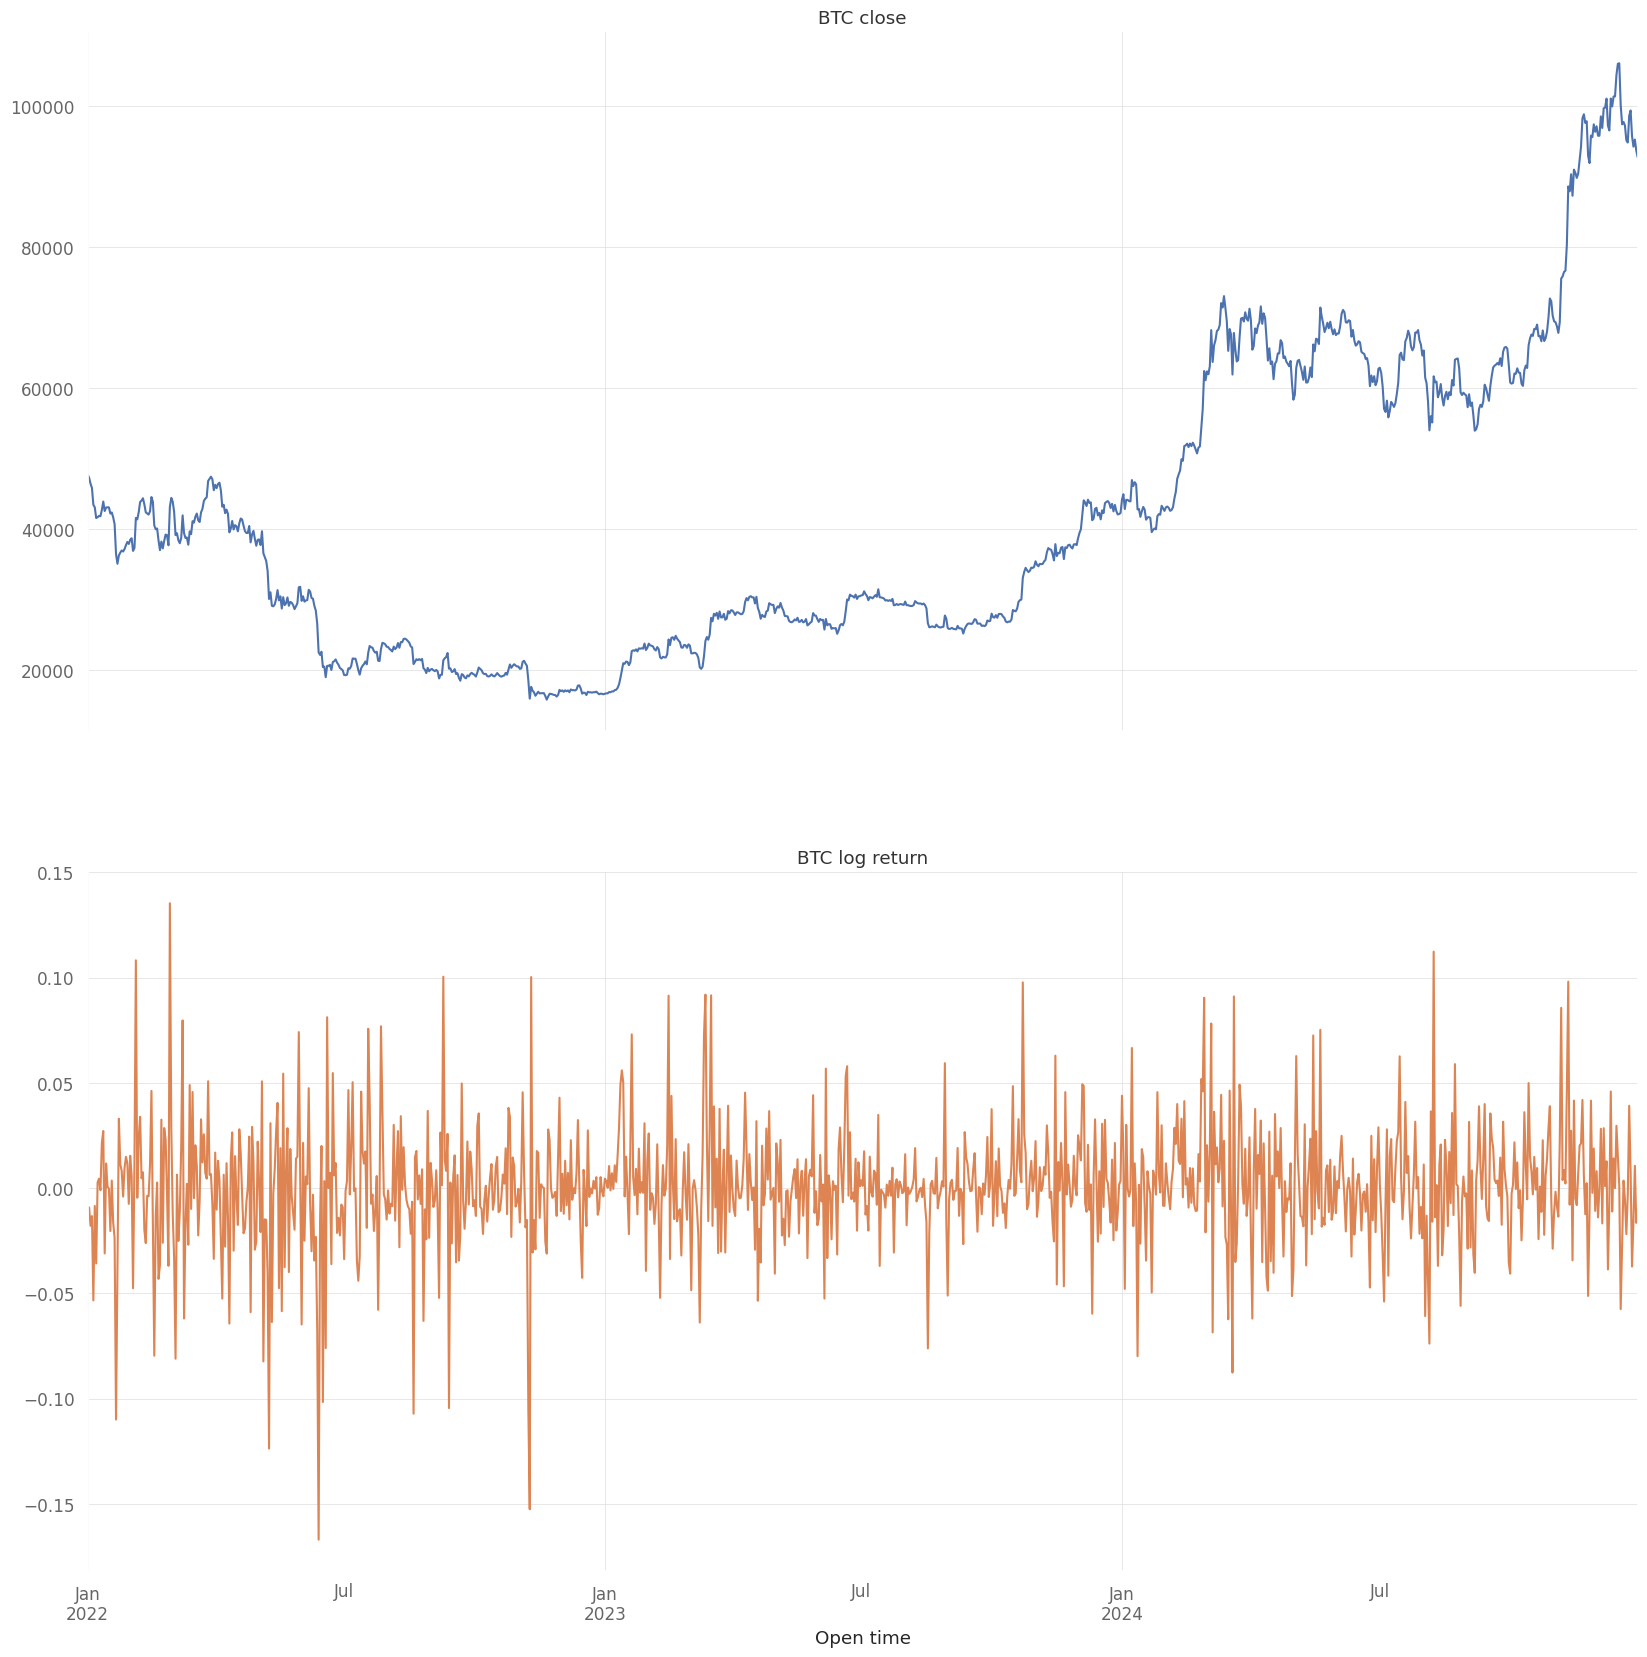

In [4]:
plot_df = pd.concat(
    {
        "BTC close": close,
        "BTC log return": log_return,
    },
    axis=1,
)

plot_df.plot(
    subplots=True,
    figsize=(20, 20),
    title=["BTC close", "BTC log return"],
    layout=(2, 1),
    legend=False,
);

In [5]:
def normal_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def variance_ratio_test(log_prices: pd.Series, q: int) -> pd.Series:
    """Lo-MacKinlay style variance ratio summary using overlapping returns."""
    y = pd.Series(log_prices).dropna()
    n = len(y)
    mu = (y.iloc[-1] - y.iloc[0]) / (n - 1)

    one_period = y.diff().dropna()
    var_1 = ((one_period - mu) ** 2).sum() / (n - 2)

    q_period = y.diff(q).dropna()
    m = q * (n - q + 1) * (1 - q / n)
    var_q = ((q_period - q * mu) ** 2).sum() / m

    vr = var_q / var_1
    z_stat = (vr - 1.0) / math.sqrt((2.0 * (2.0 * q - 1.0) * (q - 1.0)) / (3.0 * q * n))
    p_value = 2.0 * (1.0 - normal_cdf(abs(z_stat)))

    if vr < 1:
        interpretation = "mean reversion"
    elif vr > 1:
        interpretation = "momentum / trending"
    else:
        interpretation = "random walk"

    return pd.Series(
        {
            "lag": q,
            "variance_ratio": vr,
            "z_stat": z_stat,
            "p_value": p_value,
            "reject_random_walk_5pct": p_value < 0.05,
            "interpretation": interpretation,
        }
    )

In [6]:
lags = [2, 5, 10, 20, 30]

vr_results = pd.DataFrame(
    [variance_ratio_test(log_price, q) for q in lags]
).set_index("lag")

vr_results

,variance_ratio,z_stat,p_value,reject_random_walk_5pct,interpretation
lag,,,,,
2,0.987328,-0.419341,0.674967,False,mean reversion
5,1.052590,0.794308,0.427016,False,momentum / trending
10,1.065140,0.638413,0.523205,False,momentum / trending
20,1.091116,0.606670,0.544070,False,momentum / trending
30,1.085033,0.456326,0.648155,False,momentum / trending


In [7]:
summary_df = vr_results.copy()
summary_df["verdict_5pct"] = np.where(
    summary_df["reject_random_walk_5pct"],
    "reject random walk",
    "fail to reject random walk",
)
summary_df[["variance_ratio", "z_stat", "p_value", "interpretation", "verdict_5pct"]]

,variance_ratio,z_stat,p_value,interpretation,verdict_5pct
lag,,,,,
2,0.987328,-0.419341,0.674967,mean reversion,fail to reject random walk
5,1.052590,0.794308,0.427016,momentum / trending,fail to reject random walk
10,1.065140,0.638413,0.523205,momentum / trending,fail to reject random walk
20,1.091116,0.606670,0.544070,momentum / trending,fail to reject random walk
30,1.085033,0.456326,0.648155,momentum / trending,fail to reject random walk


## Interpretation

If the variance ratio stays below 1 across multiple lags, the series shows slower diffusion than a random walk, which is consistent with mean reversion. If it stays near 1 and the p-values are large, the data are hard to distinguish from a random walk.